# misc_americano — DELETE mask for compositing

Builds a **per-frame mask table** that marks Gaussians to **KEEP** on the background after **removing** chosen pseudo-label IDs (cup / pitcher / hand / espresso region — whatever you list).

This mirrors **Section B / Option B2** in `generate_mask_tables.ipynb` (split-cookie), but paths default to **HyperNeRF `misc_americano`**.

**Saved tensor meaning:** `mask_table[t, n] == True` means Gaussian `n` is **kept** at frame `t`. Rows where the removed IDs dominated are **False** (those Gaussians are later zeroed in opacity when you export the composite PLY in the other notebook).

**Before you run:** set `AMERICANO_REMOVE_IDS` using IDs from your pseudo masks (`data/hypernerf/misc_americano/pseudo_label/object_mask/*.png`) or from the classifier preview in Section 2.

In [1]:
import os, time
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
import torch
import numpy as np
from matplotlib import pyplot as plt
from argparse import ArgumentParser
from tqdm import tqdm
from arguments import ModelParams, PipelineParams, ModelHiddenParams
from scene import Scene, GaussianModel
from gaussian_renderer import render, render_contrastive_feature, render_segmentation
from utils.segment_utils import get_combined_args, visualize_obj, to8b
import mmcv
from utils.params_utils import merge_hparams

%load_ext autoreload
%autoreload 2

def load_feature_gaussians(model_path, cfg_path='./arguments/hypernerf/default.py'):
    """Load scene in feature mode (access _mlp / _classifier)."""
    parser = ArgumentParser()
    model_p = ModelParams(parser, sentinel=True)
    pipeline_p = PipelineParams(parser)
    hp = ModelHiddenParams(parser)
    parser.add_argument('--iteration', default=-1, type=int)
    parser.add_argument('--mode', default='feature')
    parser.add_argument('--configs', type=str, default=cfg_path)

    args = get_combined_args(parser, model_path, 'feature')
    config = mmcv.Config.fromfile(args.configs)
    args = merge_hparams(args, config)

    dataset = model_p.extract(args)
    hyperparam = hp.extract(args)
    pipeline = pipeline_p.extract(args)

    dataset.object_masks = True
    dataset.need_gt_masks = True

    gaussians = GaussianModel(dataset.sh_degree, 'feature', hyperparam, dataset.feature_dim)
    scene = Scene(dataset, gaussians, load_iteration=args.iteration, mode='feature')

    bg_color = [1, 1, 1] if dataset.white_background else [0, 0, 0]
    bg_color_t = torch.tensor(bg_color, dtype=torch.float32, device='cuda')
    bg_feature = torch.zeros(dataset.feature_dim, dtype=torch.float32, device='cuda')

    train_cams = list(scene.getTrainCameras())
    video_cams = list(scene.getVideoCameras())
    print(f'train views: {len(train_cams)}, video views: {len(video_cams)}')
    return gaussians, scene, pipeline, bg_color_t, bg_feature, train_cams, video_cams

print('Helpers OK')

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Helpers OK


## 1. Paths (defaults = repo-relative `sa4d` cwd)

Run Jupyter with **working directory** = `.../new_sa4d/sa4d`.

In [2]:
# ── misc_americano (HyperNeRF) ──
AMERICANO_MODEL = './output/hypernerf/misc_americano'
CFG = './arguments/hypernerf/default.py'

g_am, scene_am, pipe_am, bg_am, bgf_am, train_am, vid_am = load_feature_gaussians(AMERICANO_MODEL, CFG)
print(f'Total Gaussians in misc_americano: {g_am.get_xyz.shape[0]}')

Looking for config file in ./output/hypernerf/misc_americano/feature_cfg_args
Config file found at: ./output/hypernerf/misc_americano/feature_cfg_args
ID Encoding Dimension:  32
mode:  feature
Loading trained model at iteration 14000
load finished


132it [00:00, 79296.49it/s]

format finished


Loading Training Cameras
Loading Test Cameras
Loading Video Cameras
Deformation Net Set aabb [ 7.9026313  6.572209  32.661182 ] [-10.831657 -20.024147  16.978903]
Voxel Plane: set aabb= Parameter containing:
tensor([[  7.9026,   6.5722,  32.6612],
        [-10.8317, -20.0241,  16.9789]])
loading model from exists./output/hypernerf/misc_americano/point_cloud/iteration_14000
train views: 132, video views: 526
Total Gaussians in misc_americano: 366377


## 2. Pick REMOVE IDs (classifier preview)

Use the middle panel to read integer IDs at pixels covering **cup / pitcher / hand** (whatever you want gone). Update `AMERICANO_REMOVE_IDS` in the **next** cell.

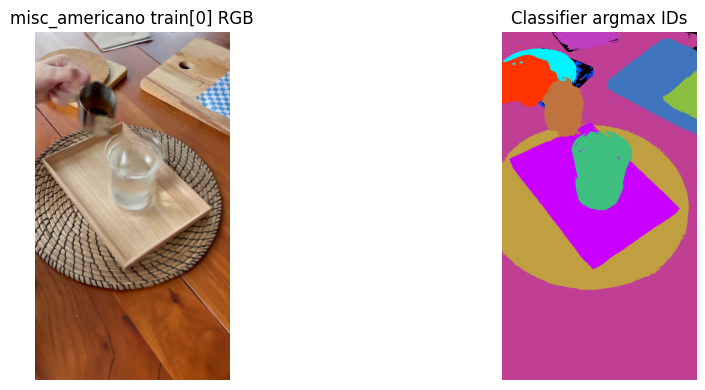

Top IDs by pixel count:
  ID  16  →  235463 pixels
  ID  18  →   92003 pixels
  ID  11  →   71937 pixels
  ID  22  →   33159 pixels
  ID  12  →   27599 pixels
  ID  13  →   16482 pixels
  ID  26  →   13971 pixels
  ID  17  →    7074 pixels
  ID   2  →    6879 pixels
  ID  24  →    6408 pixels
  ID   0  →    2544 pixels
  ID   1  →    1041 pixels


In [3]:
REF_IDX = 0   # training frame index for preview
ref_view_am = train_am[REF_IDX]

with torch.no_grad():
    rendering = render(ref_view_am, g_am, pipe_am, bg_am)['render']
    img_am = to8b(rendering).transpose(1, 2, 0)

    identity_encoding = render_contrastive_feature(ref_view_am, g_am, pipe_am, bgf_am)['render']
    logits = g_am._classifier(identity_encoding)
    pred_obj = torch.argmax(logits, dim=0).cpu().numpy()

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.imshow(img_am)
plt.title(f'misc_americano train[{REF_IDX}] RGB')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(visualize_obj(pred_obj))
plt.title('Classifier argmax IDs')
plt.axis('off')
plt.tight_layout()
plt.show()

unique_ids, counts = np.unique(pred_obj, return_counts=True)
print("Top IDs by pixel count:")
for cnt, uid in sorted(zip(counts, unique_ids), reverse=True)[:25]:
    print(f"  ID {uid:3d}  →  {cnt:6d} pixels")

Will save: misc_americano_delete_rulesumprob_mc0.8_mrp0.35_noq_norad.pt


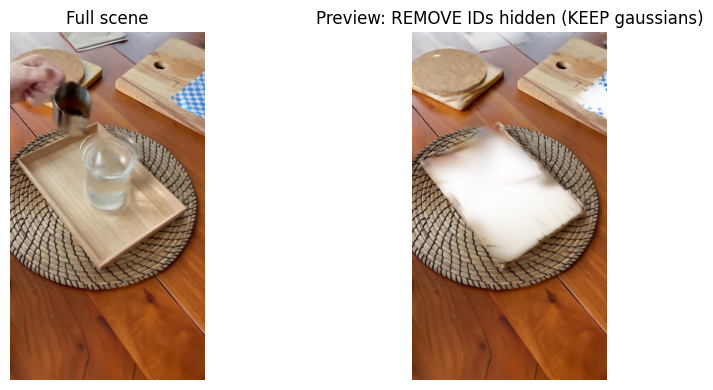

Gaussians tagged for removal (this frame): 80394 / 366377


In [5]:
# ═══ EDIT THESE ═══
AMERICANO_OUT_NAME = None   # or e.g. 'misc_americano_delete_manual_name'

# Replace using your pseudo / classifier map.
AMERICANO_REMOVE_IDS = [12, 13, 26, 2, 0, 1, 24, 11]   # cup / pitcher / hand / etc. — UPDATE

# Removal rule:
# - top1: remove if top-1 ID is in REMOVE_IDS AND top-1 prob > MIN_CONFIDENCE_AM
# - sumprob (recommended): remove if total prob mass over REMOVE_IDS > MIN_REMOVE_PROB_AM
# - union: OR of the two rules
AM_REMOVE_RULE = 'sumprob'  # 'sumprob' | 'top1' | 'union'

MIN_CONFIDENCE_AM = 0.8
MIN_REMOVE_PROB_AM = 0.35

# Optional cleanup/expansion in 3D.
# Outlier trimming can *cause* remnants; keep it off unless you need it.
OUTLIER_PERCENTILE_AM = None  # e.g. 0.90, or None to disable
EXPAND_RADIUS_AM = 0.0        # e.g. 0.01–0.03 (scene units) to catch uncertain neighbors

selected_remove = torch.tensor(AMERICANO_REMOVE_IDS, device='cuda', dtype=torch.long)

if AMERICANO_OUT_NAME is None:
    tag = f"rule{AM_REMOVE_RULE}_mc{MIN_CONFIDENCE_AM:g}_mrp{MIN_REMOVE_PROB_AM:g}"
    tag += "_noq" if OUTLIER_PERCENTILE_AM is None else f"_q{OUTLIER_PERCENTILE_AM:g}"
    tag += "_norad" if EXPAND_RADIUS_AM <= 0 else f"_rad{EXPAND_RADIUS_AM:g}"
    AMERICANO_OUT_NAME = f"misc_americano_delete_{tag}"

print(f'Will save: {AMERICANO_OUT_NAME}.pt')

def compute_remove_mask_for_time(t_scalar: float) -> torch.Tensor:
    """Returns bool mask over gaussians to REMOVE at time t."""
    means3D = g_am.get_xyz
    ts = torch.tensor(t_scalar, device=means3D.device).repeat(means3D.shape[0], 1)
    ie = g_am._mlp(means3D, ts)
    logits3d = g_am._classifier(ie.unsqueeze(1).permute(2, 0, 1))
    prob3d = torch.softmax(logits3d, dim=0)

    top_id = torch.argmax(prob3d, dim=0).squeeze()
    top_prob = prob3d.max(dim=0).values.squeeze()

    mask_top1 = torch.zeros_like(top_id, dtype=torch.bool)
    for oid in selected_remove:
        mask_top1 |= (top_id == oid) & (top_prob > MIN_CONFIDENCE_AM)

    remove_prob = prob3d.index_select(0, selected_remove).sum(dim=0).squeeze()
    mask_sumprob = remove_prob > MIN_REMOVE_PROB_AM

    if AM_REMOVE_RULE == 'top1':
        mask_remove = mask_top1
    elif AM_REMOVE_RULE == 'sumprob':
        mask_remove = mask_sumprob
    elif AM_REMOVE_RULE == 'union':
        mask_remove = mask_top1 | mask_sumprob
    else:
        raise ValueError(f'Unknown AM_REMOVE_RULE={AM_REMOVE_RULE!r}')

    if mask_remove.any() and OUTLIER_PERCENTILE_AM is not None:
        sel_xyz = means3D[mask_remove]
        ctr = sel_xyz.mean(dim=0)
        ds = (sel_xyz - ctr).norm(dim=-1)
        cut = ds.quantile(float(OUTLIER_PERCENTILE_AM))
        inl = ds <= cut
        clean = torch.zeros_like(mask_remove)
        clean[mask_remove] = inl
        mask_remove = clean

    if mask_remove.any() and EXPAND_RADIUS_AM and EXPAND_RADIUS_AM > 0:
        sel_xyz = means3D[mask_remove]
        min_d2 = torch.full((means3D.shape[0],), float('inf'), device=means3D.device)
        chunk = 65536
        for s in range(0, means3D.shape[0], chunk):
            xyz_c = means3D[s:s+chunk]
            d = torch.cdist(xyz_c, sel_xyz).min(dim=1).values
            min_d2[s:s+chunk] = d * d
        mask_remove = mask_remove | (min_d2 <= (EXPAND_RADIUS_AM ** 2))

    return mask_remove

with torch.no_grad():
    mask_remove = compute_remove_mask_for_time(ref_view_am.time)
    keep_preview = ~mask_remove
    del_render = render_segmentation(ref_view_am, g_am, pipe_am, bg_am, keep_preview)['render']
    del_img = to8b(del_render.detach()).transpose(1, 2, 0)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img_am)
plt.title('Full scene')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(del_img)
plt.title('Preview: REMOVE IDs hidden (KEEP gaussians)')
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"Gaussians tagged for removal (this frame): {mask_remove.sum().item()} / {g_am.get_xyz.shape[0]}")

## 4. Build + save DELETE mask table (`KEEP` = `~remove` per frame)

Writes under `output/hypernerf/misc_americano/segment_results/<name>.pt`.

Use that path as **`MASK0`** in `composite_misc_americano_torchocolate.ipynb` (same `mc`/`q` filename).

In [6]:
interval_am = 1
num_samples_am = (len(train_am) + interval_am - 1) // interval_am
g_am.create_mask_table(num_samples_am)
count_am = 0

print(f'Building KEEP mask table over {num_samples_am} timestamps...')
print(
    '  '
    f'REMOVE_IDS={AMERICANO_REMOVE_IDS}, '
    f'RULE={AM_REMOVE_RULE}, '
    f'MIN_CONF={MIN_CONFIDENCE_AM}, '
    f'MIN_REMOVE_PROB={MIN_REMOVE_PROB_AM}, '
    f'OUTLIER_Q={OUTLIER_PERCENTILE_AM}, '
    f'EXPAND_RADIUS={EXPAND_RADIUS_AM}'
)

t0 = time.time()

with torch.no_grad():
    for idx, view in enumerate(tqdm(train_am)):
        if idx % interval_am:
            continue
        g_am._time_map[count_am] = view.time

        mask3d_r = compute_remove_mask_for_time(view.time)

        # STORE KEEP (invert remove), same convention as split-cookie delete mask
        g_am._mask_table[count_am] = ~mask3d_r
        count_am += 1

print(f'Done in {time.time()-t0:.1f}s')

save_dir_am = os.path.join(AMERICANO_MODEL, 'segment_results')
os.makedirs(save_dir_am, exist_ok=True)
g_am.save_mask_table(
    save_dir_am,
    AMERICANO_OUT_NAME,
    {
        'rule': AM_REMOVE_RULE,
        'min_confidence': MIN_CONFIDENCE_AM,
        'min_remove_prob': MIN_REMOVE_PROB_AM,
        'outlier_percentile': OUTLIER_PERCENTILE_AM,
        'expand_radius': EXPAND_RADIUS_AM,
        'interval': interval_am,
        'removed_ids': AMERICANO_REMOVE_IDS,
    },
)
print(f'Saved to {save_dir_am}/{AMERICANO_OUT_NAME}.pt')

Building KEEP mask table over 132 timestamps...
  REMOVE_IDS=[12, 13, 26, 2, 0, 1, 24, 11], RULE=sumprob, MIN_CONF=0.8, MIN_REMOVE_PROB=0.35, OUTLIER_Q=None, EXPAND_RADIUS=0.0


100%|██████████| 132/132 [00:04<00:00, 31.26it/s]

Done in 4.2s
Saved to ./output/hypernerf/misc_americano/segment_results/misc_americano_delete_rulesumprob_mc0.8_mrp0.35_noq_norad.pt


In [15]:
# List recent mask tables
import glob
folder = os.path.abspath(os.path.join(AMERICANO_MODEL, 'segment_results'))
for p in sorted(glob.glob(folder + '/*.pt'))[-15:]:
    print(p)

/home/ubuntu/new_sa4d/sa4d/output/hypernerf/misc_americano/segment_results/misc_americano_delete_mc0.8_q0.9.pt
/home/ubuntu/new_sa4d/sa4d/output/hypernerf/misc_americano/segment_results/misc_americano_ids16-18_q0.95_mc0.pt
/home/ubuntu/new_sa4d/sa4d/output/hypernerf/misc_americano/segment_results/misc_americano_ids16-18_q0.95_mc0_objmasks.pt
/home/ubuntu/new_sa4d/sa4d/output/hypernerf/misc_americano/segment_results/misc_americano_mc0.5_q0.95_ids18.pt
/home/ubuntu/new_sa4d/sa4d/output/hypernerf/misc_americano/segment_results/misc_americano_pseudo_ids16-18_q0.95.pt
/home/ubuntu/new_sa4d/sa4d/output/hypernerf/misc_americano/segment_results/misc_americano_pseudo_ids16-18_q0.95_trimdef.pt
/home/ubuntu/new_sa4d/sa4d/output/hypernerf/misc_americano/segment_results/misc_americano_pseudo_ids16-18_q0.95_trimdef_pp.pt
/home/ubuntu/new_sa4d/sa4d/output/hypernerf/misc_americano/segment_results/misc_americano_pseudo_ids16-18_q0.95_trimdef_pp_minfrac25.pt
/home/ubuntu/new_sa4d/sa4d/output/hypernerf/m